# 04 — Government Fiscal Impact

Scale individual-level retirement outcomes to a DoD aggregate cost
comparison under High-Three and BRS.

**Government cost definition (actuarial cost basis):**  
The government’s retirement cost per person is the NPV of its actual
cash outlays — pension payments plus TSP contributions made during
service. Both are valued at the separation date using the 5% discount
rate and expressed in constant 2026 dollars (matching 03a).
TSP investment returns are earned inside the member’s account
by financial markets, not by DoD, so they are excluded from
DoD’s cost.

| Component | High-Three | BRS |
|---|---|---|
| Pension NPV | 2.5% × YOS × High-3 base | 2.0% × YOS × High-3 base |
| Govt TSP cost | None | PV of govt contributions (1%→5%) at the 5% discount rate |

`GovtTSP_PV` = PV at separation of government TSP
contributions (1% automatic in YOS 1–2; 1% + 4% match = 5%
from YOS 3), with basic pay grown at 2.75%/yr, each
contribution compounded forward at 5% to the separation
date, then deflated to 2026 dollars. This is the actuarial
“normal cost” of TSP contributions, consistent with how
pension NPV is discounted.

The comparison table below quantifies how this choice affects the result.

**Scenario weighting:**  
P(sep at YOS y) = Survival(y−1) − Survival(y) from the DoD actuarial
table. Non-modeled YOS values are binned to the nearest modeled
scenario (midpoint assignment). Weights sum to 1 per profile.

**Inputs:** `deterministic_results.csv`, `withdrawal_rates.csv`,
`pay_profiles.csv`  
**Outputs:** `data/processed/fiscal_results.csv`,
`data/processed/scenario_weights.csv`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../src")))

PROCESSED = Path("../data/processed")

## Constants and data

In [2]:
YOS_SCENARIOS = list(range(4, 41, 2))  # 4-40, step 2
PROFILE_SCENARIOS = {
    "Officer": YOS_SCENARIOS,
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": YOS_SCENARIOS,
}

DISCOUNT_RATE = 0.05      # nominal NPV rate (matches 03a/03b)
PAY_GROWTH = 0.0275       # pay raises track COLA (matches 03a)

# Display order for cross-profile tables and charts
PROFILE_ORDER = [
    "Enlisted", "PriorEnlistedOfficer", "Officer"
]

# Chart palette. System bars (cost charts): BRS = bright blue,
# H3 = bright amber. Difference charts shade the two halves with
# the muted slate/brown versions of the same hues (kept faint as
# a background), labeled "BRS advantage" / "High-Three advantage".
BRS_COLOR = "#00274C"    # Michigan blue
H3_COLOR = "#FFCB05"     # Michigan maize
BRS_REGION = "#4B6C8F"   # light blue (BRS-advantage half)
H3_REGION = "#FFE57F"    # light maize (High-Three-advantage half)

# Approximate annual active-component accessions.
# Source: DoD FY2024 Population Representation report.
OFFICER_ACCESSIONS = 18_000
ENLISTED_ACCESSIONS = 140_000

det = pd.read_csv(PROCESSED / "deterministic_results.csv")
wr = pd.read_csv(PROCESSED / "withdrawal_rates.csv")
pay = pd.read_csv(PROCESSED / "pay_profiles.csv")

print(f"Scenarios loaded:           {len(det)}")
print(
    f"Withdrawal table YOS range: "
    f"{wr['YOS'].min()}–{wr['YOS'].max()}"
)
print(f"Pay profile rows:           {len(pay)}")

Scenarios loaded:           52
Withdrawal table YOS range: 1–40
Pay profile rows:           110


## Government cost per separating member

For each scenario, isolate what the **government** pays
(constant 2026 `$`):

- **H3_GovtCost** = H3PensionNPV — pension only; no TSP
- **GovtTSP_PV** = actuarial PV at separation of government
  TSP contributions, as defined in the header; computed from
  `pay_profiles.csv`
- **BRS_GovtCost** = BRSPensionNPV + GovtTSP_PV
- **DoD_Savings** = H3_GovtCost − BRS_GovtCost
  (positive = BRS costs less for DoD)

For members separating before 20 YOS, no pension vests under
either system. H3_GovtCost = 0; BRS still incurs GovtTSP_PV,
so DoD_Savings is negative for all pre-retirement separations.

A comparison cell quantifies the actuarial vs. entitlement
TSP values at representative career lengths. The entitlement
premium is largest for short careers — every dollar
contributed then has decades of glide-path growth to age 60
above the 5% discount rate — and shrinks as that growth
window closes (the ratio falls from ~2.6x at 4 YOS toward
~1.5x at 40).

In [3]:
from tsp_calcs import brs_govt_rate  # noqa: E402


def govt_tsp_actuarial(pay_df, profile, sep_yos):
    """
    PV at separation of govt TSP contributions, 2026 $.

    Pay grows at PAY_GROWTH. Each year's government
    contribution (brs_govt_rate x nominal annual pay: 1%
    in YOS 1-2, 5% from YOS 3) is compounded forward to
    the separation date at DISCOUNT_RATE, then deflated
    to 2026 dollars - matching the reference date,
    discount rate, and units used for pension NPV.
    """
    career = pay_df.query(
        "Profile == @profile and YOS <= @sep_yos"
    ).set_index("YOS")["MonthlyPay"]
    total = 0.0
    for yos, monthly_pay in career.items():
        nom = monthly_pay * (1 + PAY_GROWTH) ** (yos - 1)
        contrib = nom * 12 * brs_govt_rate(yos)
        years = sep_yos - yos
        total += contrib * (1 + DISCOUNT_RATE) ** years
    return total / (1 + PAY_GROWTH) ** sep_yos


fiscal = det.copy()
fiscal["GovtTSP_PV"] = [
    govt_tsp_actuarial(pay, r["Profile"], r["SepYOS"])
    for _, r in fiscal.iterrows()
]
fiscal["H3_GovtCost"] = fiscal["H3PensionNPV"]
fiscal["BRS_GovtCost"] = (
    fiscal["BRSPensionNPV"] + fiscal["GovtTSP_PV"]
)
fiscal["DoD_Savings"] = (
    fiscal["H3_GovtCost"] - fiscal["BRS_GovtCost"]
)

print(
    "Actuarial vs. entitlement TSP cost"
    " (Officer, 2026 $ thousands):"
)
print(
    f"  {'SepYOS':>8} {'Actuarial (5%)':>16}"
    f" {'Entitlement (mkt)':>19} {'Ratio':>7}"
)
print("  " + "-" * 54)
show_yos = [4, 12, 20, 30, 40]
for _, row in fiscal[
    (fiscal["Profile"] == "Officer")
    & fiscal["SepYOS"].isin(show_yos)
].iterrows():
    act = row["GovtTSP_PV"] / 1000
    ent = (
        row["BRS_TSP_PV"] - row["H3TSP_PV"]
    ) / 1000
    ratio = ent / act if act > 0 else float("nan")
    print(
        f"  {int(row['SepYOS']):>8d}"
        f" {'$' + format(act, ',.1f'):>16}"
        f" {'$' + format(ent, ',.1f'):>19}"
        f" {ratio:>7.2f}x"
    )

Actuarial vs. entitlement TSP cost (Officer, 2026 $ thousands):
    SepYOS   Actuarial (5%)   Entitlement (mkt)   Ratio
  ------------------------------------------------------
         4             $9.2               $24.4    2.64x
        12            $53.6              $119.4    2.23x
        20           $119.4              $229.5    1.92x
        30           $244.8              $398.6    1.63x
        40           $426.6              $620.4    1.45x


## Government cost by system and YOS

This is the pension cliff in government dollars: cost per
member is near zero before 20 YOS (BRS TSP contributions
only), then jumps to `$0.9–1.7M` the moment the pension vests,
with the BRS bars 8–14% below High-Three throughout 20+ YOS.

Note that the Prior-Enlisted Officer bars overtake the Officer
bars at the longest careers (~38–40 YOS). This is an age effect,
not a pay effect: at equal YOS the PEO is four years younger at
separation (entry age 18 vs 22) and collects the pension ~3 more
expected years, while the basic-pay cap compresses the two
profiles' High-3 bases together late in a career (the
annual-pension gap shrinks from ~28% at 24 YOS to ~3% at 40).
Pension cost is annual amount × years collected, so the longer
payment window wins once the pay gap closes. The same trade
explains why the Officer High-Three cost flattens from 36 YOS and
dips slightly by 40: each extra year of service adds little to a
capped pension but removes a full year of collection. (The BRS
bar still creeps up through 40 because the government TSP cost
keeps accruing with each year served.)


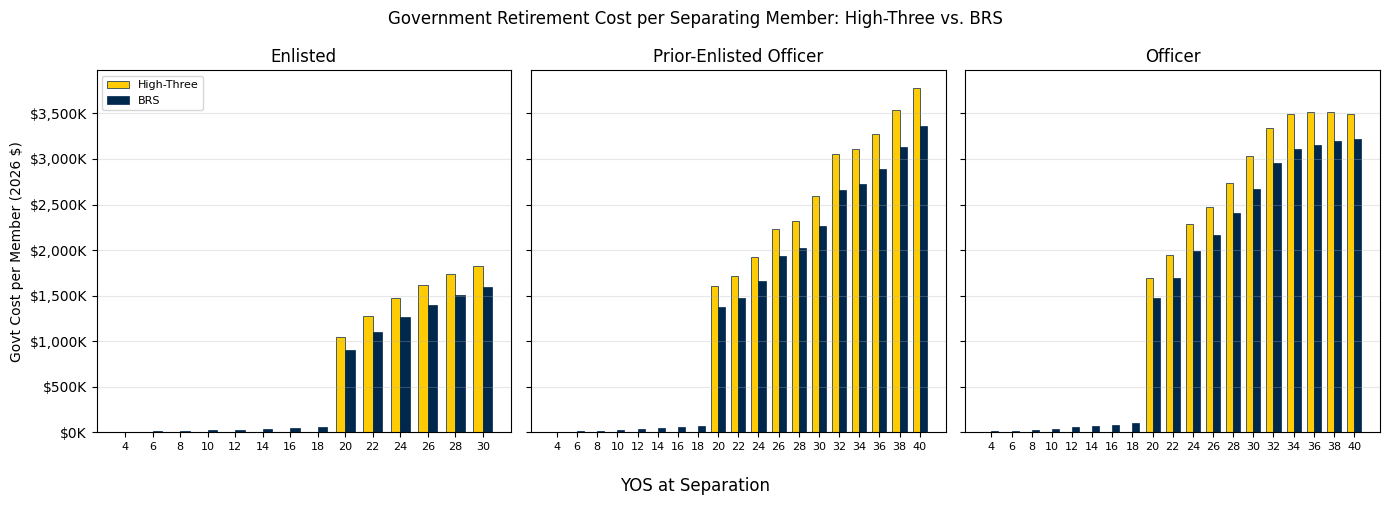

In [4]:
profile_labels = {
    "Enlisted": "Enlisted",
    "PriorEnlistedOfficer": "Prior-Enlisted Officer",
    "Officer": "Officer",
}

fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

bar_w = 0.35
for ax, (profile, label) in zip(
    axes, profile_labels.items()
):
    sub = fiscal[fiscal["Profile"] == profile].copy()
    x = np.arange(len(sub))

    ax.bar(
        x - bar_w / 2,
        sub["H3_GovtCost"] / 1000,
        width=bar_w,
        label="High-Three",
        color=H3_COLOR,
        edgecolor="#00274C",
        linewidth=0.5,
    )
    ax.bar(
        x + bar_w / 2,
        sub["BRS_GovtCost"] / 1000,
        width=bar_w,
        label="BRS",
        color=BRS_COLOR,
        edgecolor="#00274C",
        linewidth=0.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        sub["SepYOS"].astype(str), fontsize=8
    )
    ax.set_title(label)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda v, _: f"${v:,.0f}K"
        )
    )
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Govt Cost per Member (2026 $)")
fig.supxlabel("YOS at Separation")
fig.suptitle(
    "Government Retirement Cost per Separating Member"
    ": High-Three vs. BRS",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Effect of switching from High-Three to BRS

For each career length, the chart shows what changes if BRS
replaces High-Three — on the member's ledger and on DoD's:

- **Change in member lifetime value** (03a, `BRSAdv`):
  pension NPV plus the full TSP value at market returns,
  including glide-path growth to age 60.
- **Change in DoD cost** (this notebook): pension NPV plus
  only the government's TSP contributions, compounded at
  the 5% discount rate.

Pre-20, BRS gives the member more and costs DoD more;
post-20 it takes value from the member and saves DoD money.
The member line sits above the DoD line at every YOS
(Officer/20: member −`$110K` vs −`$220K` DoD cost change),
and the shaded gap is funded by investment returns rather
than government outlays — the comparison is not zero-sum.
In one line: **every government dollar spent buys the
member two, and every government dollar saved only costs
the member half.**


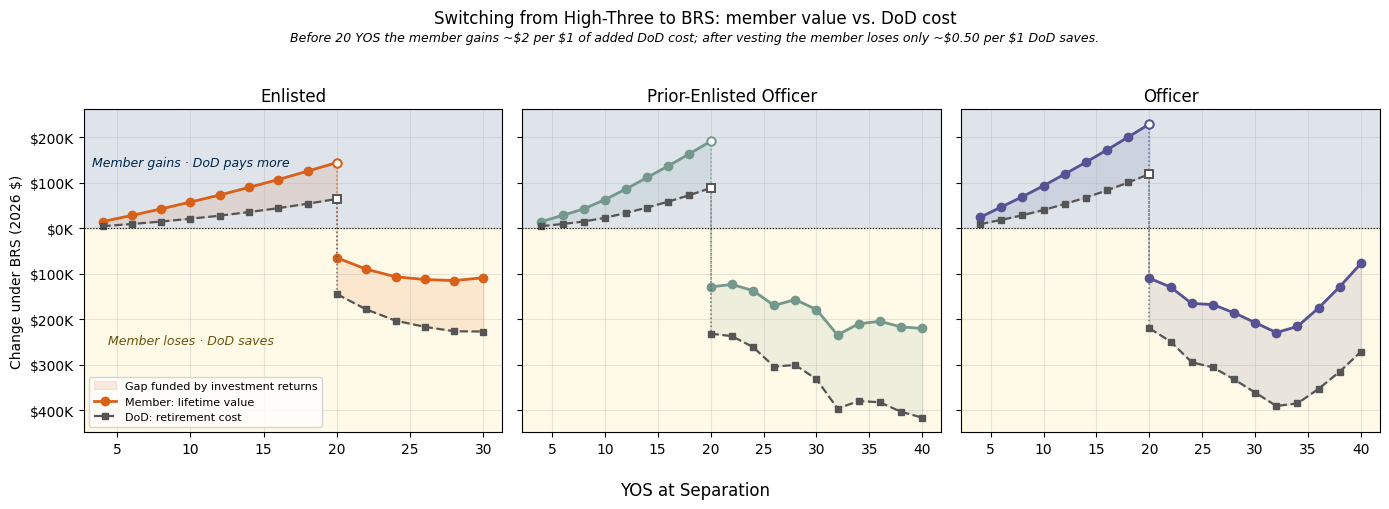

In [5]:
profile_colors = {
    "Enlisted": "#D86018",
    "PriorEnlistedOfficer": "#75988d",
    "Officer": "#575294",
}
DOD_COLOR = "#555555"

det_idx = det.set_index(["Profile", "SepYOS"])
fis_idx = fiscal.set_index(["Profile", "SepYOS"])

fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

for ax, profile in zip(axes, PROFILE_ORDER):
    sub = (
        fiscal[fiscal["Profile"] == profile]
        .sort_values("SepYOS")
    )
    yos = sub["SepYOS"].to_numpy()
    member = (
        det_idx.loc[profile].reindex(yos)["BRSAdv"]
        .to_numpy() / 1000
    )
    govt = -sub["DoD_Savings"].to_numpy() / 1000
    # Value on the cusp of vesting at 20 (no pension yet): the
    # member's TSP-only difference and the govt's TSP-only cost,
    # the natural continuation of each pre-20 line.
    m_cusp = (
        det_idx.loc[(profile, 20), "BRS_TSP_PV"]
        - det_idx.loc[(profile, 20), "H3TSP_PV"]
    ) / 1000
    g_cusp = fis_idx.loc[(profile, 20), "GovtTSP_PV"] / 1000

    c = profile_colors[profile]
    pre = yos < 20
    post = yos >= 20
    xpre = list(yos[pre]) + [20]

    # Shaded gap between the two ledgers = funded by returns
    ax.fill_between(
        xpre, list(member[pre]) + [m_cusp],
        list(govt[pre]) + [g_cusp],
        color=c, alpha=0.12,
        label="Gap funded by investment returns",
    )
    ax.fill_between(
        yos[post], member[post], govt[post],
        color=c, alpha=0.12,
    )
    # Member line (= 03a BRS - H3), broken at the 20-yr cliff:
    # pre to the cusp (open marker), dotted drop, then 20+.
    ax.plot(
        xpre, list(member[pre]) + [m_cusp],
        "-o", color=c, lw=2, label="Member: lifetime value",
    )
    ax.plot(
        [20], [m_cusp], "o", mfc="white", mec=c,
        mew=1.4, zorder=6,
    )
    ax.plot(
        [20, 20], [m_cusp, member[post][0]],
        ls=":", color=c, lw=1.1, alpha=0.8,
    )
    ax.plot(yos[post], member[post], "-o", color=c, lw=2)
    # DoD cost line, broken at the cliff the same way (open
    # square at the cusp, mirroring the member's open circle)
    ax.plot(
        xpre, list(govt[pre]) + [g_cusp],
        "--s", color=DOD_COLOR, lw=1.6, ms=4,
        label="DoD: retirement cost",
    )
    ax.plot(
        [20], [g_cusp], "s", mfc="white", mec=DOD_COLOR,
        mew=1.4, zorder=6,
    )
    ax.plot(
        [20, 20], [g_cusp, govt[post][0]],
        ls=":", color=DOD_COLOR, lw=1.1, alpha=0.8,
    )
    ax.plot(
        yos[post], govt[post], "--s",
        color=DOD_COLOR, lw=1.6, ms=4,
    )

    ax.axhline(
        0, color="black", linewidth=0.8, linestyle=":"
    )
    ax.set_title(profile_labels[profile])
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda v, _: f"${abs(v):,.0f}K"
        )
    )

# Shade by what happens to each party (same vocabulary as the
# lines), avoiding the BRS/H3 "advantage" framing that would
# only describe the member line: above zero BRS adds value &
# cost, below zero it cuts both.
ymin, ymax = axes[0].get_ylim()
for ax in axes:
    ax.axhspan(0, ymax, color=BRS_REGION, alpha=0.18, zorder=0)
    ax.axhspan(ymin, 0, color=H3_REGION, alpha=0.18, zorder=0)
    ax.set_ylim(ymin, ymax)

axes[0].legend(fontsize=8, loc="lower left")
axes[0].text(
    10, ymax * 0.55, "Member gains · DoD pays more",
    ha="center", va="center", fontsize=9, style="italic",
    color="#00274C",
)
axes[0].text(
    10, ymin * 0.55, "Member loses · DoD saves",
    ha="center", va="center", fontsize=9, style="italic",
    color="#6b540f",
)
axes[0].set_ylabel("Change under BRS (2026 $)")
fig.supxlabel("YOS at Separation")
fig.suptitle(
    "Switching from High-Three to BRS:"
    " member value vs. DoD cost",
    fontsize=12, y=0.99,
)
fig.text(
    0.5, 0.925,
    r"Before 20 YOS the member gains ~\$2 per \$1 of added"
    r" DoD cost; after vesting the member loses only"
    r" ~\$0.50 per \$1 DoD saves.",
    ha="center", fontsize=9, style="italic",
)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

## Separation probability weights

The probability that a random entrant separates at each YOS comes
from the DoD actuarial withdrawal and survival tables:

P(sep at YOS y) = Survival(y−1) − Survival(y), where Survival(0) = 1

Since the model covers a discrete 2-year scenario grid, each
possible YOS (1–40) is assigned to the nearest modeled scenario by absolute
distance (ties go to the lower scenario). Weights sum to 1.
The save cell persists the exact weights to
`scenario_weights.csv` (consumed by notebook 05 and the app).

**PriorEnlistedOfficer:** officer withdrawal rates are applied for
the full career. Prior-enlisted officers are a self-selected subgroup
likely to exhibit officer career patterns after commissioning.

In [6]:
def sep_probs_by_yos(wr_df, surv_col):
    """
    Separation probability at each YOS 1–40.

    Returns
    -------
    dict  {yos (int): probability (float)}
    """
    probs = {}
    surv_prev = 1.0
    for _, row in wr_df.iterrows():
        yos = int(row["YOS"])
        surv = float(row[surv_col])
        probs[yos] = surv_prev - surv
        surv_prev = surv
    return probs


def bin_to_scenarios(probs, scenarios):
    """
    Aggregate per-YOS probabilities to modeled scenarios.

    Each YOS is assigned to the nearest scenario (ties
    go to the lower value).

    Returns
    -------
    pd.Series  indexed by scenario YOS, summing to ≈1
    """
    scenarios = sorted(scenarios)
    weights = {s: 0.0 for s in scenarios}
    for yos, prob in probs.items():
        dists = [abs(yos - s) for s in scenarios]
        nearest = scenarios[dists.index(min(dists))]
        weights[nearest] += prob
    return pd.Series(weights, name="Weight")


surv_col_map = {
    "Enlisted": "EnlistedSurvival",
    "PriorEnlistedOfficer": "OfficerSurvival",
    "Officer": "OfficerSurvival",
}

scenario_weights = {}
for profile, surv_col in surv_col_map.items():
    probs = sep_probs_by_yos(wr, surv_col)
    scenarios = PROFILE_SCENARIOS[profile]
    scenario_weights[profile] = bin_to_scenarios(
        probs, scenarios
    )

sums = "  ".join(
    f"{p}={w.sum():.4f}"
    for p, w in scenario_weights.items()
)
print(f"Weight sums (should be 1): {sums}")

Weight sums (should be 1): Enlisted=1.0000  PriorEnlistedOfficer=1.0000  Officer=1.0000


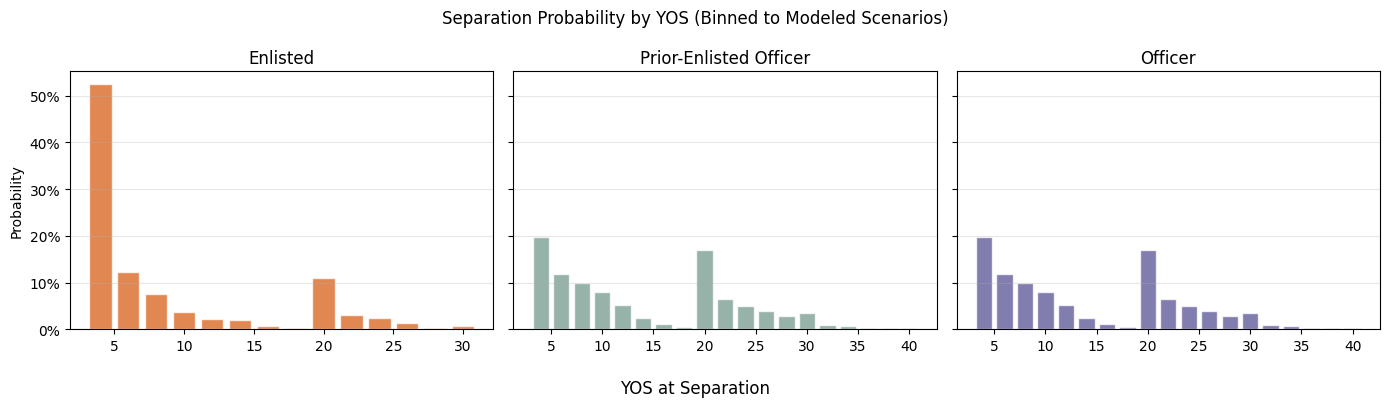

In [7]:
fig, axes = plt.subplots(
    1, 3, figsize=(14, 4), sharey=True
)

for ax, (profile, label) in zip(
    axes, profile_labels.items()
):
    w = scenario_weights[profile]
    ax.bar(
        w.index,
        w.values,
        width=1.6,
        color=profile_colors[profile],
        alpha=0.75,
        edgecolor="white",
    )
    ax.set_title(label)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.0%}")
    )
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Probability")
fig.supxlabel("YOS at Separation")
fig.suptitle(
    "Separation Probability by YOS"
    " (Binned to Modeled Scenarios)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Expected government cost per entering service member

Multiplying each scenario's government cost by its separation
probability and summing gives the expected cost per entrant — the
actuarial present value of retirement obligations for a member
entering service today, before their eventual career length is known.

Because ~59% of officers and ~81% of enlisted separate before
20 YOS, the TSP costs paid to early separatees under BRS accumulate
across a large population. Whether that cost exceeds the pension
savings for career retirees depends on the full distribution.

**Behavior held fixed:** the weights are historical DoD
actuarial rates. BRS itself may change stay/go decisions (a
portable TSP makes leaving before 20 less costly), which is
deliberately not modeled — notebook 05's separation-shift
sensitivity quantifies how a hypothetical shift toward
earlier separation would erode the savings.

**Why PEO saves DoD the most:** the savings side (the 20%
pension cut) is officer-scale for PEOs — their High-3 comes
from O-4+ years — while the cost side (govt TSP
contributions) is enlisted-scale for their first 8 years.
Officer-sized pension savings minus enlisted-sized TSP cost
beats either pure profile (12.5% of H3 cost vs ~10.5–10.7%
for Enlisted/Officer).


In [8]:
records = []
for profile in PROFILE_ORDER:
    w = scenario_weights[profile]
    sub = (
        fiscal[fiscal["Profile"] == profile]
        .set_index("SepYOS")
    )
    h3_exp = (
        w * sub.reindex(w.index)["H3_GovtCost"]
    ).sum()
    brs_exp = (
        w * sub.reindex(w.index)["BRS_GovtCost"]
    ).sum()
    tsp_exp = (
        w * sub.reindex(w.index)["GovtTSP_PV"]
    ).sum()
    brs_pen_exp = (
        w * sub.reindex(w.index)["BRSPensionNPV"]
    ).sum()
    records.append({
        "Profile": profile,
        "H3_Expected": h3_exp,
        "BRS_Expected": brs_exp,
        "BRS_PensionExp": brs_pen_exp,
        "BRS_TSPExp": tsp_exp,
        "Savings_PerEntrant": h3_exp - brs_exp,
        "Savings_Pct": (
            (h3_exp - brs_exp) / h3_exp
            if h3_exp > 0 else float("nan")
        ),
    })

expected = pd.DataFrame(records)

print(
    f"Computed expected costs for"
    f" {len(expected)} profiles."
)

Computed expected costs for 3 profiles.


### Cost component breakdown

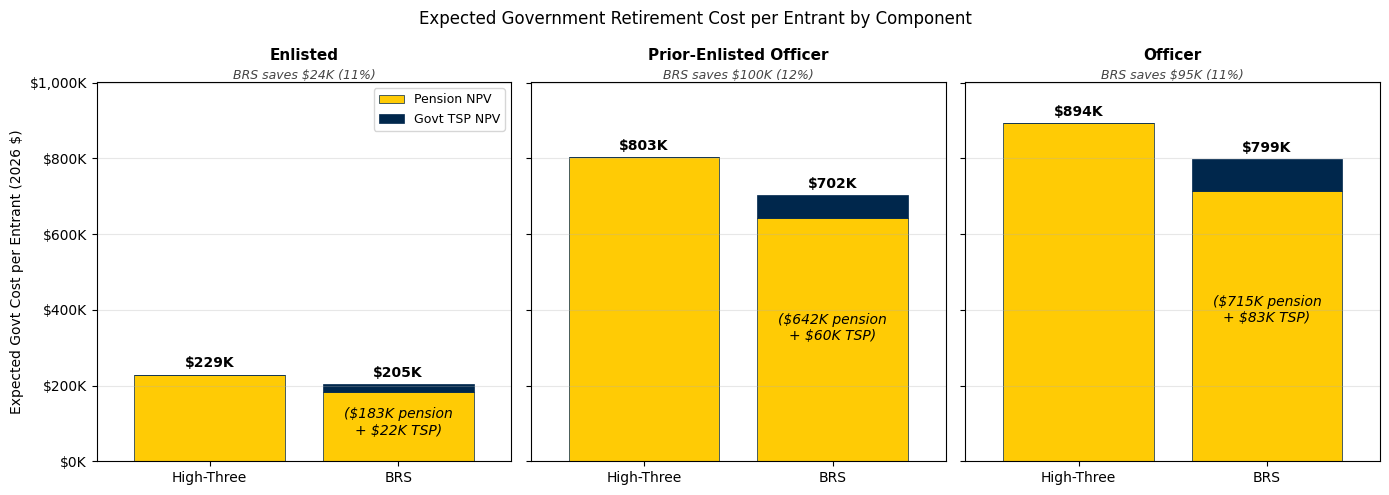

In [9]:
fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

for ax, profile in zip(axes, PROFILE_ORDER):
    row = expected.set_index("Profile").loc[profile]
    systems = ["High-Three", "BRS"]
    pension_vals = [
        row["H3_Expected"] / 1000,
        row["BRS_PensionExp"] / 1000,
    ]
    tsp_vals = [0.0, row["BRS_TSPExp"] / 1000]
    totals = [
        pension_vals[0],
        pension_vals[1] + tsp_vals[1],
    ]
    x = np.arange(len(systems))

    ax.bar(
        x, pension_vals, label="Pension NPV",
        color=H3_COLOR, edgecolor="#00274C", linewidth=0.5,
    )
    ax.bar(
        x, tsp_vals, bottom=pension_vals,
        label="Govt TSP NPV", color=BRS_COLOR,
        edgecolor="#00274C", linewidth=0.5,
    )

    # Bold total above each bar; the BRS bar's component split
    # sits inside it as a two-line italic parenthetical (same
    # size/color as the totals).
    for i in range(2):
        ax.annotate(
            rf"\${totals[i]:,.0f}K",
            xy=(i, totals[i]), xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold",
        )
    ax.annotate(
        rf"(\${pension_vals[1]:,.0f}K pension"
        "\n"
        rf"+ \${tsp_vals[1]:,.0f}K TSP)",
        xy=(1, totals[1] / 2),
        ha="center", va="center",
        fontsize=10, style="italic",
    )

    # Bold profile label, with the headline savings as an
    # italic subtitle just beneath (open space, no crowding;
    # it is also the H3 - BRS gap shown by the bars).
    sav = totals[0] - totals[1]
    pct = sav / totals[0]
    ax.set_title(
        profile_labels[profile], fontsize=11,
        fontweight="bold", pad=16,
    )
    ax.text(
        0.5, 1.0,
        rf"BRS saves \${sav:,.0f}K ({pct:.0%})",
        transform=ax.transAxes, ha="center", va="bottom",
        fontsize=9, style="italic", color="#444",
    )
    ax.set_xlim(-0.6, 1.6)
    ax.set_xticks(x)
    ax.set_xticklabels(systems)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v:,.0f}K")
    )
    ax.grid(axis="y", alpha=0.3)

ymax = expected["H3_Expected"].max() / 1000
axes[0].set_ylim(0, ymax * 1.12)
axes[0].legend(fontsize=9, loc="upper right")
axes[0].set_ylabel("Expected Govt Cost per Entrant (2026 $)")
fig.suptitle(
    "Expected Government Retirement Cost per Entrant"
    " by Component",
    fontsize=12,
)
plt.tight_layout()
plt.show()

### Where the spending goes: early separatees vs. retirees

Splitting expected per-entrant cost by who receives it —
E[cost] = P(sep < 20)·E[cost | sep < 20] +
P(20+)·E[cost | 20+] — shows that BRS barely changes the
*direction* of DoD's retirement spending. Under High-Three,
100% of spending goes to the minority who reach 20 YOS, by
construction; under BRS only ~1–4% reaches the ≤19 YOS
majority. The savings come from paying retirees less (12–14%
less per retiree), not from redistribution.

The pension cliff is also visible in government dollars:
serving the 20th year raises DoD's obligation by roughly
`$0.8–1.7M` depending on profile and system — BRS softens
the cliff only modestly on the cost side.

**Caveat:** these are DoD actuarial costs. The member-side
*value* of the early-separatee TSP benefit is roughly twice
the government's cost (market growth to age 60 — see the
actuarial-vs-entitlement table above), so the cost share
understates the benefit share from the member's perspective.


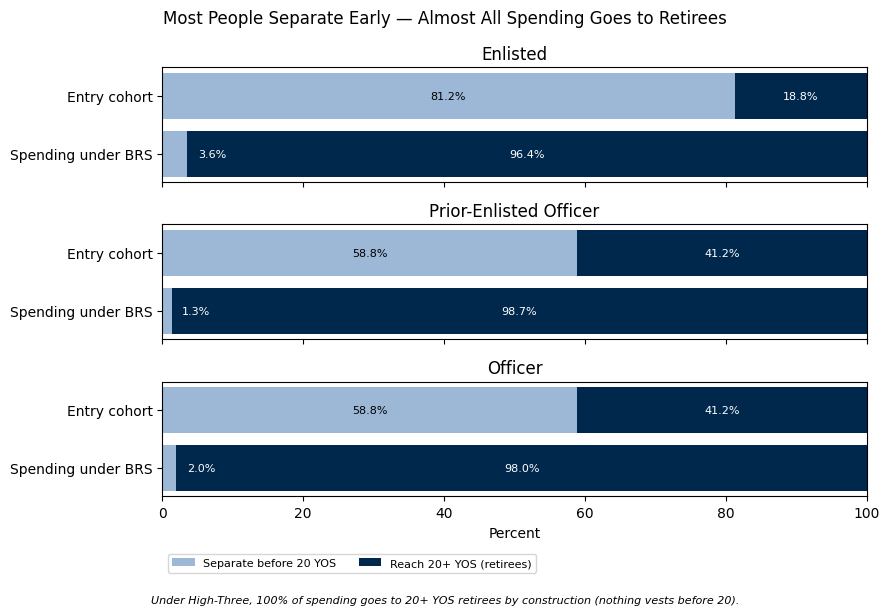

In [10]:
# Share of expected spending reaching early separatees,
# and expected cost per retiree, by profile and system
EARLY_COLOR = "#9CB8D6"    # early separatees (< 20 YOS), light blue
RETIREE_COLOR = "#00274C"  # retirees (20+ YOS) — get the money

split = {}
for profile in PROFILE_ORDER:
    w = scenario_weights[profile]
    sub = (
        fiscal[fiscal["Profile"] == profile]
        .set_index("SepYOS")
        .reindex(w.index)
    )
    early = w.index < 20
    p_early = float(w[early].sum())
    share, per_retiree = {}, {}
    for col in ("H3_GovtCost", "BRS_GovtCost"):
        tot = float((w * sub[col]).sum())
        to_e = float(
            (w[early] * sub[col][early]).sum()
        )
        share[col] = to_e / tot
        per_retiree[col] = (tot - to_e) / (1.0 - p_early)
    split[profile] = (p_early, share, per_retiree)

fig, axes = plt.subplots(
    3, 1, figsize=(9, 6), sharex=True
)
rows = [
    "Entry cohort",
    "Spending under BRS",
]

for ax, profile in zip(axes, PROFILE_ORDER):
    p_early, share, _ = split[profile]
    early_v = [
        p_early * 100,
        share["BRS_GovtCost"] * 100,
    ]
    late_v = [100 - v for v in early_v]
    y = np.arange(len(rows))

    ax.barh(
        y, early_v, color=EARLY_COLOR,
        label="Separate before 20 YOS",
    )
    ax.barh(
        y, late_v, left=early_v, color=RETIREE_COLOR,
        label="Reach 20+ YOS (retirees)",
    )
    for yi, (e, l) in enumerate(zip(early_v, late_v)):
        if e >= 12:
            ax.text(
                e / 2, yi, f"{e:.1f}%",
                ha="center", va="center",
                fontsize=8, color="black",
            )
        else:
            ax.text(
                e + 1.5, yi, f"{e:.1f}%",
                ha="left", va="center",
                fontsize=8, color="white",
            )
        ax.text(
            e + l / 2, yi, f"{l:.1f}%",
            ha="center", va="center",
            fontsize=8, color="white",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(rows)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_title(profile_labels[profile])

axes[-1].set_xlabel("Percent")
axes[-1].legend(
    fontsize=8, loc="upper left",
    bbox_to_anchor=(0.0, -0.45), ncols=2,
)
fig.text(
    0.5, -0.01,
    "Under High-Three, 100% of spending goes to 20+ YOS"
    " retirees by construction (nothing vests before 20).",
    ha="center", fontsize=8, style="italic",
)
fig.suptitle(
    "Most People Separate Early — Almost All Spending"
    " Goes to Retirees",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Monte Carlo uncertainty — DoD savings per entrant

The deterministic analysis uses fixed COLA / pay growth (2.75%)
and life expectancy (SSA 2022 male mean). In the MC, the COLA
draw drives basic-pay growth, the pension COLA, and the 2026-`$`
deflator, so every component — including `GovtTSP_PV` — varies
across iterations.

**Methodology:**
- N = 20,000 iterations
- COLA: one draw per iteration, **shared across all scenarios**
  (Normal fit on rolling 30-year average CPI, matching 03b;
  floored at 0 — the draw represents lifetime-average
  inflation, held constant within an iteration)
- Pay growth: basic pay grows at the iteration's COLA draw, so
  the High-Three base and govt TSP contributions are stochastic
- Death age: independent draw per scenario per iteration
  (empirical SSA 2022 conditional age-at-death, sampled from
  the actuarial table)
- All values deflated to constant 2026 dollars
- Per-entrant savings: separation-weighted sum computed
  **inside** each iteration, preserving cross-scenario COLA
  correlation

In [11]:
from monte_carlo import (  # noqa: E402
    fit_cola_stats,
    govt_tsp_pv_vec,
    high3_base_vec,
    mean_death_age,
    npv_pension_vec,
    sample_death_age,
)

N_ITER = 20_000
# COLA draw = lifetime-average inflation; rolling-average
# fit matches the 03b parameterization
COLA_WINDOW = 30

cpi = pd.read_csv(PROCESSED / "cpi_inflation.csv")
life_exp = pd.read_csv(PROCESSED / "life_expectancy.csv")
cola_params = fit_cola_stats(cpi, window=COLA_WINDOW)

print(
    f"COLA: mean={cola_params['mean']:.2%}"
    f"  std={cola_params['std']:.2%}"
    f"  (rolling {COLA_WINDOW}-yr avg CPI)"
)
print("Deterministic baseline (DoD actuarial): 2.75%")
print(
    "Death age: empirical SSA 2022 conditional age-at-death"
)
print(f"MC iterations: {N_ITER:,}")

COLA: mean=3.39%  std=1.27%  (rolling 30-yr avg CPI)
Deterministic baseline (DoD actuarial): 2.75%
Death age: empirical SSA 2022 conditional age-at-death
MC iterations: 20,000


In [12]:
rng = np.random.default_rng(42)

# One COLA draw per iteration, shared across scenarios;
# drives pay growth, pension COLA, and the 2026-$ deflator
cola_v = np.maximum(
    rng.normal(
        cola_params["mean"], cola_params["std"], N_ITER
    ),
    0.0,
)


def pay_series(profile, sep_yos):
    """2026-table monthly pay through sep_yos."""
    return (
        pay.query(
            "Profile == @profile and YOS <= @sep_yos"
        )
        .set_index("YOS")["MonthlyPay"]
    )


def sim_scenario_savings(
    rng_, cola_arr, rows, death_stochastic=True
):
    """
    Per-scenario DoD savings arrays (constant 2026 $).

    One death-age draw per 20+ YOS scenario, sampled from the
    empirical SSA conditional age-at-death distribution using
    rng_ in row order, so a given (rng_, rows) pair yields a
    reproducible draw sequence. death_stochastic=False holds
    death age at its conditional mean (used for force-level
    aggregation, where mortality averages out across the
    cohort).
    """
    n = len(cola_arr)
    out = {}
    for _, row in rows.iterrows():
        prof = row["Profile"]
        sep_yos = int(row["SepYOS"])
        sep_age = int(row["SepAge"])
        p_ser = pay_series(prof, sep_yos)
        defl_v = (1.0 + cola_arr) ** sep_yos
        govt_tsp_v = govt_tsp_pv_vec(
            p_ser, cola_arr, sep_yos, DISCOUNT_RATE
        )
        if sep_yos >= 20:
            base_v = high3_base_vec(p_ser, cola_arr)
            h3_ann_v = base_v * 12.0 * 0.025 * sep_yos
            brs_ann_v = base_v * 12.0 * 0.020 * sep_yos
            if death_stochastic:
                death_v = np.clip(
                    sample_death_age(
                        life_exp, sep_age, n, rng_
                    ),
                    float(sep_age), 120.0,
                )
            else:
                death_v = np.full(
                    n, mean_death_age(life_exp, sep_age)
                )
            n_pens_v = death_v - float(sep_age)
            h3_v = npv_pension_vec(
                h3_ann_v, cola_arr, DISCOUNT_RATE,
                n_pens_v
            )
            brs_v = npv_pension_vec(
                brs_ann_v, cola_arr, DISCOUNT_RATE,
                n_pens_v
            )
            out[(prof, sep_yos)] = (
                h3_v - brs_v - govt_tsp_v
            ) / defl_v
        else:
            out[(prof, sep_yos)] = -govt_tsp_v / defl_v
    return out


# Per-scenario DoD savings arrays (constant 2026 $)
scenario_savings = sim_scenario_savings(
    rng, cola_v, fiscal
)

# Separation-weighted per-entrant savings distribution
pe_savings = {}
for profile in PROFILE_ORDER:
    w = scenario_weights[profile]
    weighted_v = np.zeros(N_ITER)
    for sep_yos_key, weight in w.items():
        weighted_v += (
            weight
            * scenario_savings[(profile, sep_yos_key)]
        )
    pe_savings[profile] = weighted_v

print(
    f"Simulated {N_ITER:,} iterations across"
    f" {len(scenario_savings)} scenarios."
)

Simulated 20,000 iterations across 52 scenarios.


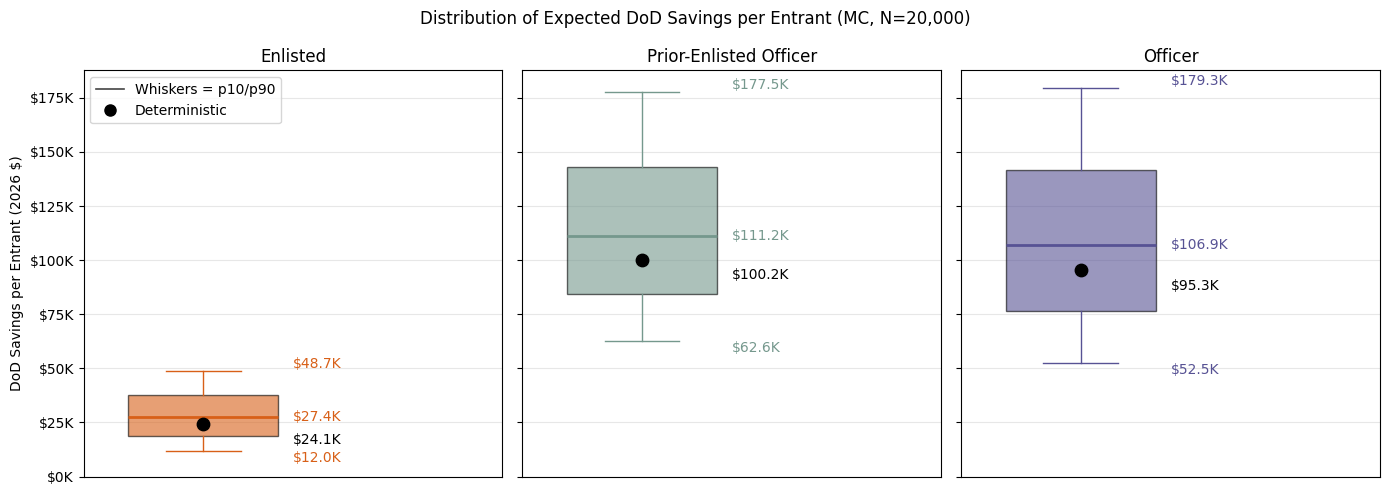

In [13]:
plot_profiles = PROFILE_ORDER
fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)

for ax, profile in zip(axes, plot_profiles):
    sv = pe_savings[profile] / 1000
    det_val = (
        expected
        .set_index("Profile")
        .loc[profile, "Savings_PerEntrant"] / 1000
    )
    p10, p50, p90 = np.percentile(sv, [10, 50, 90])

    c = profile_colors[profile]
    bp = ax.boxplot(
        sv,
        positions=[0],
        widths=0.5,
        whis=[10, 90],
        showfliers=False,
        patch_artist=True,
        medianprops={"color": c, "linewidth": 2},
        boxprops={"facecolor": c, "alpha": 0.6},
        whiskerprops={"color": c},
        capprops={"color": c},
    )
    ax.scatter(0, det_val, color="black", zorder=5, s=80)
    # Box sits near the left; labels fill the space to its right
    ax.set_xlim(-0.4, 1.0)
    ax.set_xticks([])
    ax.set_title(profile_labels[profile])
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda v, _: f"${v:,.0f}K"
        )
    )
    ax.grid(axis="y", alpha=0.3)

    # Dollar amounts only (the legend defines each marking).
    # Profile color = MC stats; black = deterministic.
    for val, va in [
        (p90, "bottom"),
        (p50, "center"),
        (p10, "top"),
    ]:
        ax.annotate(
            f"${val:,.1f}K", xy=(0.3, val),
            fontsize=10, color=c, va=va,
        )
    ax.annotate(
        f"${det_val:,.1f}K",
        xy=(0.3, det_val), xytext=(0, -6),
        textcoords="offset points",
        fontsize=10, color="black", va="top",
    )

axes[0].set_ylim(bottom=0)  # floor at $0 - no data is negative
axes[0].set_ylabel(
    "DoD Savings per Entrant (2026 $)"
)

# The box (IQR) and median line are standard; only the two
# less-obvious markings get a key - the p10/p90 whiskers (the
# default whisker is 1.5*IQR) and the deterministic dot. Empty
# plot() calls supply proxy handles without drawing data.
whisker_handle = axes[0].plot(
    [], [], color="#444444", lw=1.2
)[0]
det_handle = axes[0].plot(
    [], [], marker="o", color="black", ls="None", ms=8
)[0]
axes[0].legend(
    [whisker_handle, det_handle],
    ["Whiskers = p10/p90", "Deterministic"],
    loc="upper left", fontsize=10,
)

fig.suptitle(
    "Distribution of Expected DoD Savings per Entrant"
    " (MC, N=20,000)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Convergence check — Officer per-entrant savings

Is 20,000 iterations enough? Test on the most volatile
metric: Officer per-entrant savings (largest pension values
and widest spread). Run 40,000 iterations and track each
reported statistic as N grows. The chart shows each
statistic's deviation from its final N=40K value; the shaded
band is the stability criterion (±1% of the P10–P90 outcome
spread — the same criterion as 03b). Estimates must enter
the band and stay there. The table then applies the
criterion quantitatively at the half-to-full step (N=20K vs
N=40K).


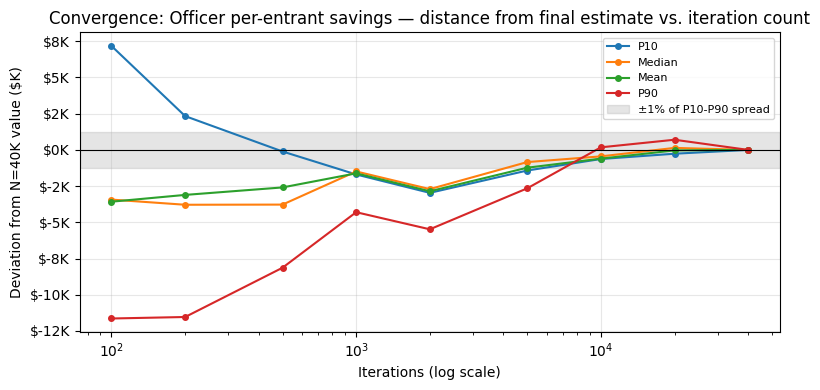

P10-P90 spread at N=40K: $126.7K

     Stat   N=20K ($K)   N=40K ($K)  Shift ($K)   % spread
  ----------------------------------------------------------
      P10        +52.0        +52.3        +0.3      0.21%
   Median       +106.8       +106.7        -0.1      0.11%
     Mean       +112.3       +112.3        +0.0      0.03%
      P90       +179.7       +179.0        -0.7      0.55%

Max shift 20K->40K: 0.55% of spread (on P90) -> PASS (threshold 1%)


In [14]:
N_CONV = 40_000
rng_cv = np.random.default_rng(42)

cola_cv = np.maximum(
    rng_cv.normal(
        cola_params["mean"], cola_params["std"],
        N_CONV,
    ),
    0.0,
)

# Officer only - the metric under test. Same helper and
# row order as the main run, so the per-scenario draw
# sequence matches; only the draw count differs.
sv_cv = sim_scenario_savings(
    rng_cv, cola_cv,
    fiscal[fiscal["Profile"] == "Officer"],
)

w_cv = scenario_weights["Officer"]
pe_cv = np.zeros(N_CONV)
for sep_yos_key, weight in w_cv.items():
    pe_cv += weight * sv_cv[("Officer", sep_yos_key)]

checkpoints = [
    100, 200, 500, 1_000, 2_000,
    5_000, 10_000, 20_000, 40_000,
]
conv_stats = {}
for n in checkpoints:
    sub = pe_cv[:n] / 1000
    conv_stats[n] = {
        "p10": float(np.percentile(sub, 10)),
        "p50": float(np.percentile(sub, 50)),
        "mean": float(sub.mean()),
        "p90": float(np.percentile(sub, 90)),
    }

labels = {
    "p10": "P10", "p50": "Median",
    "mean": "Mean", "p90": "P90",
}

# Stability criterion: shift < 1% of the P10-P90 spread
THRESHOLD_PCT = 1.0
final = conv_stats[40_000]
spread_40k = final["p90"] - final["p10"]
thr = spread_40k * THRESHOLD_PCT / 100

# Deviation from the final 40K estimate, so all four
# stats share a scale where the early noise is visible
fig, ax = plt.subplots(figsize=(8, 4))
for key, lbl in labels.items():
    devs = [
        conv_stats[n][key] - final[key]
        for n in checkpoints
    ]
    ax.plot(checkpoints, devs, "o-", ms=4, label=lbl)
ax.axhspan(
    -thr, thr, color="gray", alpha=0.2,
    label=f"±{THRESHOLD_PCT:.0f}% of P10-P90 spread",
)
ax.axhline(0, color="black", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel("Iterations (log scale)")
ax.set_ylabel("Deviation from N=40K value ($K)")
ax.set_title(
    "Convergence: Officer per-entrant savings —"
    " distance from final estimate vs. iteration count"
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}K")
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Half-to-full check at N=20K vs N=40K
print(f"P10-P90 spread at N=40K: ${spread_40k:,.1f}K")
print()
print(
    f"  {'Stat':>7}  {'N=20K ($K)':>11}"
    f"  {'N=40K ($K)':>11}  {'Shift ($K)':>10}"
    f"  {'% spread':>9}"
)
print("  " + "-" * 58)
shifts = {}
for key, lbl in labels.items():
    v20 = conv_stats[20_000][key]
    v40 = final[key]
    delta = v40 - v20
    pct = abs(delta) / spread_40k * 100
    shifts[key] = pct
    print(
        f"  {lbl:>7}  {v20:>+11.1f}"
        f"  {v40:>+11.1f}  {delta:>+10.1f}"
        f"  {pct:>8.2f}%"
    )
max_key = max(shifts, key=shifts.get)
verdict = (
    "PASS" if shifts[max_key] < THRESHOLD_PCT else "FAIL"
)
print()
print(
    f"Max shift 20K->40K: {shifts[max_key]:.2f}% of"
    f" spread (on {labels[max_key]}) -> {verdict}"
    f" (threshold {THRESHOLD_PCT:.0f}%)"
)

## Force-level cost projection

Multiplying per-entrant expected costs by annual accession volume
estimates the retirement liability accrued for one year's cohort of
new entrants — the annual "normal cost" addition to the DoD retirement
obligation.

**Prior-enlisted officers are intentionally excluded** from
force-level scaling: they enter service as enlisted
accessions and later commission, so the officer + enlisted
accession split already covers them — a separate PEO line
would double-count.

**Accession figures** are approximate, and the totals scale
linearly with them (±20% accessions moves every figure ±20%)
— the per-entrant numbers above are the primitive;
force-level totals are illustrative. The table below the
chart adds MC uncertainty bands, with two aggregation rules:
individual death-age luck averages out across a 158,000-member
cohort, so the bands keep only the shared COLA risk (death age
held at its conditional mean); and the Total row is the
percentile of the combined per-iteration cohort, not the sum
of the profile rows’ percentiles.

In [15]:
# PEOs enter as enlisted accessions and are already
# counted in this split; a separate PEO line would
# double-count (see the section note above)
accession_map = {
    "Enlisted": ENLISTED_ACCESSIONS,
    "Officer": OFFICER_ACCESSIONS,
}

agg_rows = []
for profile, n in accession_map.items():
    row = expected.set_index("Profile").loc[profile]
    h3_agg = n * row["H3_Expected"]
    brs_agg = n * row["BRS_Expected"]
    savings_agg = h3_agg - brs_agg
    agg_rows.append({
        "Profile": profile,
        "Accessions": n,
        "H3_Obligation_M": h3_agg / 1e6,
        "BRS_Obligation_M": brs_agg / 1e6,
        "Savings_M": savings_agg / 1e6,
    })

agg = pd.DataFrame(agg_rows)

print(
    f"Annual accessions: "
    f"{OFFICER_ACCESSIONS:,} officers, "
    f"{ENLISTED_ACCESSIONS:,} enlisted"
)


Annual accessions: 18,000 officers, 140,000 enlisted


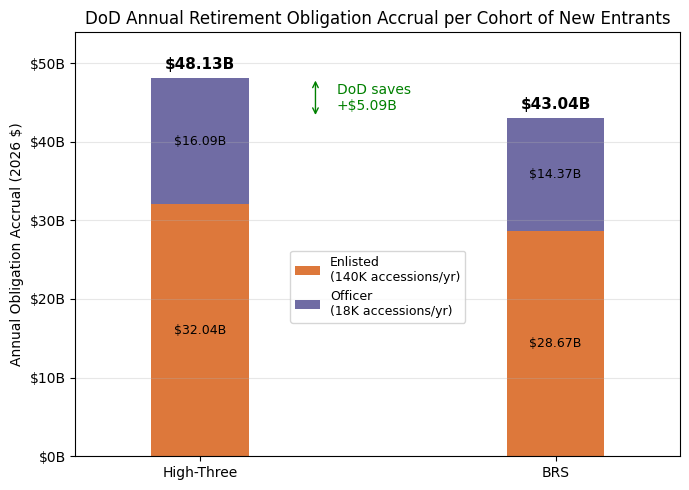

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

systems = [
    ("High-Three", "H3_Obligation_M"),
    ("BRS", "BRS_Obligation_M"),
]
positions = [0, 2]  # spread the two bars apart
agg_i = agg.set_index("Profile")

for pos, (label, col) in zip(positions, systems):
    bottom = 0.0
    for profile in ["Enlisted", "Officer"]:
        val = agg_i.loc[profile, col] / 1000
        n = int(agg_i.loc[profile, "Accessions"])
        ax.bar(
            pos, val, width=0.55, bottom=bottom,
            color=profile_colors[profile], alpha=0.85,
            label=(
                f"{profile}\n({n // 1000}K accessions/yr)"
                if pos == positions[0] else None
            ),
        )
        ax.annotate(
            f"${val:,.2f}B",
            xy=(pos, bottom + val / 2),
            ha="center", va="center",
            fontsize=9, color="black",
        )
        bottom += val
    ax.annotate(
        f"${bottom:,.2f}B",
        xy=(pos, bottom), xytext=(0, 4),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
    )

h3_tot = agg["H3_Obligation_M"].sum() / 1000
brs_tot = agg["BRS_Obligation_M"].sum() / 1000
sav = h3_tot - brs_tot
mid = (positions[0] + positions[1]) / 2
# Green double-headed arrow marks the H3-vs-BRS gap (matching
# nb05's obligation chart); savings labeled beside it.
arrow_x = mid - 0.35
ax.annotate(
    "", xy=(arrow_x, h3_tot), xytext=(arrow_x, brs_tot),
    arrowprops={"arrowstyle": "<->", "color": "green"},
)
ax.annotate(
    f"DoD saves\n+${sav:,.2f}B",
    xy=(arrow_x + 0.12, (h3_tot + brs_tot) / 2),
    ha="left", va="center",
    fontsize=10, color="green",
)

ax.set_xlim(-0.7, 2.7)
ax.set_ylim(0, h3_tot * 1.12)
ax.set_xticks(positions)
ax.set_xticklabels([s for s, _ in systems])
ax.set_ylabel("Annual Obligation Accrual (2026 $)")
ax.set_title(
    "DoD Annual Retirement Obligation Accrual"
    " per Cohort of New Entrants"
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B")
)
ax.legend(
    fontsize=9, loc="center",
    bbox_to_anchor=(0.5, 0.4),
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Mortality is idiosyncratic: across a 158,000-member
# cohort the average death age is effectively the
# population mean, so only the shared COLA draw survives
# aggregation. Force-level bands therefore hold death age
# at its conditional mean (death_stochastic=False); the
# per-entrant views above keep mortality stochastic.
force_sav = sim_scenario_savings(
    np.random.default_rng(0), cola_v, fiscal,
    death_stochastic=False,
)
pe_force = {}
for profile, n in accession_map.items():
    w = scenario_weights[profile]
    v = np.zeros(N_ITER)
    for sep_yos_key, weight in w.items():
        v += weight * force_sav[(profile, sep_yos_key)]
    pe_force[profile] = n * v

print(
    "Force-level savings with MC uncertainty"
    " (2026 $, per annual accession cohort):"
)
print(
    f"  {'Profile':12} {'N':>10}"
    f" {'p10':>10} {'p50':>10} {'p90':>10}"
    f" {'Det.':>10}"
)
print("  " + "-" * 64)


def _sfmt(v):
    """Format 2026 $ billions with explicit sign."""
    s = '+' if v >= 0 else '-'
    return f"{s + '$' + format(abs(v), ',.2f') + 'B':>10}"


det_tot = 0.0
exp_i = expected.set_index("Profile")
for profile, n in accession_map.items():
    fv = pe_force[profile]
    p10_b, p50_b, p90_b = (
        np.percentile(fv, [10, 50, 90]) / 1e9
    )
    det_b = (
        n
        * exp_i.loc[profile, "Savings_PerEntrant"]
        / 1e9
    )
    det_tot += det_b
    print(
        f"  {profile:12} {n:>10,}"
        f" {_sfmt(p10_b)} {_sfmt(p50_b)}"
        f" {_sfmt(p90_b)} {_sfmt(det_b)}"
    )
print("  " + "-" * 64)
tot_v = pe_force["Enlisted"] + pe_force["Officer"]
tp10, tp50, tp90 = (
    np.percentile(tot_v, [10, 50, 90]) / 1e9
)
tot_n = OFFICER_ACCESSIONS + ENLISTED_ACCESSIONS
print(
    f"  {'Total':12} {tot_n:>10,}"
    f" {_sfmt(tp10)} {_sfmt(tp50)}"
    f" {_sfmt(tp90)} {_sfmt(det_tot)}"
)

Force-level savings with MC uncertainty (2026 $, per annual accession cohort):
  Profile               N        p10        p50        p90       Det.
  ----------------------------------------------------------------
  Enlisted        140,000    +$2.34B    +$4.09B    +$6.36B    +$3.37B
  Officer          18,000    +$1.22B    +$2.05B    +$3.04B    +$1.72B
  ----------------------------------------------------------------
  Total           158,000    +$3.56B    +$6.14B    +$9.40B    +$5.09B


## Key findings

**Deterministic center-path:**
At 2.75% COLA / pay growth and mean life expectancy, BRS
saves DoD 10–13% of H3 retirement cost per entrant
(`$95K`/officer, `$24K`/enlisted, `$100K`/prior-enlisted officer,
constant 2026 `$`). At the force level that is ~`$5.1` billion per
annual accession cohort (`$1.7B` officer + `$3.4B` enlisted).

**Monte Carlo uncertainty (COLA + life expectancy):**
The rolling 30-year average COLA mean (3.39%) exceeds the
2.75% actuarial assumption, lifting the MC median savings
above the deterministic estimate (`$107K` vs `$95K`/officer; `$27K`
vs `$24K`/enlisted). The p10–p90 range spans `$53K` to
`$179K`/officer and `$12K` to `$49K`/enlisted per entrant — savings
stay comfortably positive across the entire range for all
three profiles. At the force level the combined cohort savings
run from +`$3.6B` (p10) to +`$9.4B` (p90) with a median of
+`$6.1B` (force bands keep only the shared COLA risk —
individual death-age luck averages out across a
158,000-member cohort). Because the COLA draw represents lifetime-average
inflation (rolling 30-year fit, std 1.27%) rather than annual
volatility, these bands honestly reflect long-horizon
uncertainty without overstating it.

**Composition, not redistribution:**
96–99% of retirement spending still goes to the minority who
reach 20 YOS; the savings come from paying each retiree
12–14% less, not from redirecting money to early separatees.
The comparison is also not zero-sum: pre-20, members gain
roughly twice what DoD spends; post-20, they lose only about
half of what DoD saves — market returns fund the wedge.

**Interpretation note:**
Separation behavior is held fixed at historical DoD actuarial
rates. BRS makes early separation more attractive, so actual
rates may shift toward more early separatees, slightly reducing
DoD savings. Behavioral retention effects are out of
scope; notebook 05’s separation-shift sensitivity bounds the
effect mechanically.


## Save output

In [18]:
out_cols = [
    "Profile", "SepYOS", "SepAge",
    "H3_GovtCost", "GovtTSP_PV",
    "BRS_GovtCost", "DoD_Savings",
]
out_path = PROCESSED / "fiscal_results.csv"
fiscal[out_cols].to_csv(out_path, index=False)
print(
    f"Saved: {out_path.name}"
    f"  ({out_path.stat().st_size / 1024:.1f} KB)"
)

# Persist separation weights so nb05 can reuse them
# without re-deriving the binning logic
weights_out = pd.concat(
    [
        w.rename("Weight")
        .rename_axis("SepYOS")
        .reset_index()
        .assign(Profile=profile)
        for profile, w in scenario_weights.items()
    ],
    ignore_index=True,
)[["Profile", "SepYOS", "Weight"]]
w_path = PROCESSED / "scenario_weights.csv"
weights_out.to_csv(w_path, index=False)
print(
    f"Saved: {w_path.name}"
    f"  ({w_path.stat().st_size / 1024:.1f} KB)"
)


Saved: fiscal_results.csv  (4.5 KB)
Saved: scenario_weights.csv  (1.8 KB)
